# Домашнее задание №1

### Задачи:
- Разработать имитационную модель одноканальной системы с отказами.
- Провести эксперименты с различными параметрами системы.
- Проанализировать полученные результаты и сделать выводы.

### ヾ(⌐■_■)ノ♪

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

np.random.seed(42)
sns.set_theme(style="whitegrid")

### Параметры системы

In [44]:
lam = 5
mu_rpc = 30
mu_resp = 40

n = 1000
T = 10000

command_types = ["GET", "SET", "DELETE"]
command_probabilities = [0.8, 0.15, 0.05]

In [55]:
def generate_execution_time(command, n):
    if command == "GET":
        scale = np.log(n) * 0.02
    elif command == "DELETE":
        scale = np.log(n) * 0.02
    elif command == "SET":
        scale = n * 0.0002

    return np.random.exponential(scale)

In [46]:
def estimate_mean_service_time(mu_rpc, mu_resp, n):

    samples = 10000
    times = []

    for _ in range(samples):

        command = np.random.choice(command_types, p=command_probabilities)

        rpc = np.random.exponential(1 / mu_rpc)
        exec_time = generate_execution_time(command, n)
        resp = np.random.exponential(1 / mu_resp)

        times.append(rpc + exec_time + resp)

    return np.mean(times)

## Симуляция системы

In [47]:
def erlang_refusal_probability(lam, mu):
    """Теоретическое значение key-value системы"""
    rho = lam / mu
    return rho / (1 + rho)

In [48]:
def simulate_system(lam, mu_rpc, mu_resp, T, n):
    """Cимуляция key-value системы"""

    current_time = 0
    server_free_time = 0

    arrived = 0
    served = 0
    rejected = 0

    busy_time = 0
    service_times = []

    requests_info = []

    request_id = 0

    while current_time < T:

        interarrival = np.random.exponential(1 / lam)
        current_time += interarrival

        if current_time > T:
            break

        arrived += 1
        request_id += 1

        command = np.random.choice(command_types, p=command_probabilities)

        rpc_time = np.random.exponential(1 / mu_rpc)
        exec_time = generate_execution_time(command, n)
        resp_time = np.random.exponential(1 / mu_resp)

        service_time = rpc_time + exec_time + resp_time

        if current_time >= server_free_time:

            served += 1

            start_time = current_time
            end_time = current_time + service_time

            server_free_time = end_time

            busy_time += service_time
            service_times.append(service_time)

            requests_info.append({
                "id": request_id,
                "command": command,
                "arrival_time": current_time,
                "start_time": start_time,
                "end_time": end_time,
                "rpc_time": rpc_time,
                "exec_time": exec_time,
                "resp_time": resp_time,
                "status": "served"
            })

        else:

            rejected += 1

            requests_info.append({
                "id": request_id,
                "command": command,
                "arrival_time": current_time,
                "status": "rejected"
            })

    refusal_probability = rejected / arrived
    utilization = busy_time / T
    throughput = served / T

    return {
        "arrived": arrived,
        "served": served,
        "rejected": rejected,
        "refusal_probability": refusal_probability,
        "utilization": utilization,
        "throughput": throughput,
        "service_times": service_times,
        "requests_info": requests_info
    }

## Проведение эксперементов

In [49]:
result = simulate_system(lam, mu_rpc, mu_resp, T, n)

print("Arrived:", result["arrived"])
print("Served:", result["served"])
print("Rejected:", result["rejected"])
print("Refusal probability:", result["refusal_probability"])
print("Utilization:", result["utilization"])

Arrived: 50108
Served: 37027
Rejected: 13081
Refusal probability: 0.26105611878342777
Utilization: 0.26124622225871474


In [50]:
mean_service_time = estimate_mean_service_time(mu_rpc, mu_resp, n)

mu_eff = 1 / mean_service_time

theoretical_refusal = erlang_refusal_probability(lam, mu_eff)

print("Mean service time:", mean_service_time)
print("Effective mu:", mu_eff)
print("Theoretical refusal probability:", theoretical_refusal)

Mean service time: 0.07131349349699444
Effective mu: 14.0225916718292
Theoretical refusal probability: 0.26284536230699646


In [34]:
comparison = pd.DataFrame({
    "Metric": [
        "Refusal probability",
        "Utilization"
    ],
    "Simulation": [
        result["refusal_probability"],
        result["utilization"]
    ],
    "Theory": [
        theoretical_refusal,
        lam / mu_eff
    ]
})

comparison

,Metric,Simulation,Theory
0,Refusal probability,0.231566,0.233976
1,Utilization,0.233146,0.305442


### Еще больше эксперементов богу эксперементов

In [35]:
lambdas = np.linspace(1, 20, 20)

sim_refusal = []
theory_refusal = []
utilizations = []
throughputs = []

for l in lambdas:

    sim = simulate_system(l, mu_rpc, mu_resp, T, n)

    sim_refusal.append(sim["refusal_probability"])
    utilizations.append(sim["utilization"])
    throughputs.append(sim["throughput"])

    theory_refusal.append(erlang_refusal_probability(l, mu_eff))

In [36]:
experiment_table = pd.DataFrame({
    "lambda": lambdas,
    "simulation_refusal": sim_refusal,
    "theoretical_refusal": theory_refusal,
    "utilization": utilizations,
    "throughput": throughputs
})

experiment_table

,lambda,simulation_refusal,theoretical_refusal,utilization,throughput
0,1.0,0.053823,0.057571,0.057893,0.9528
1,2.0,0.110240,0.108875,0.109021,1.7926
2,3.0,0.151278,0.154881,0.154156,2.5269
3,4.0,0.196684,0.196370,0.194648,3.1927
4,5.0,0.235971,0.233976,0.235471,3.8394
5,6.0,0.263637,0.268220,0.266174,4.3913
6,7.0,0.300866,0.299533,0.298604,4.9140
7,8.0,0.327256,0.328276,0.328977,5.4057
8,9.0,0.353837,0.354754,0.353341,5.8061
9,10.0,0.380040,0.379223,0.378905,6.2027


## Графики

### Теоретическая VS Симуляция

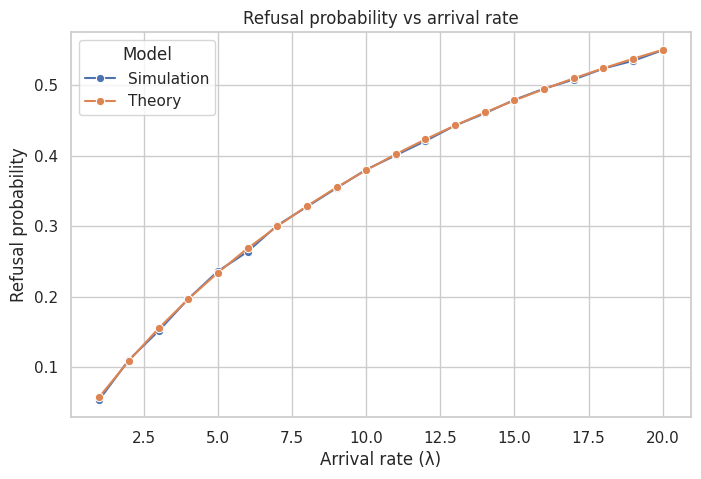

In [37]:
df_plot = pd.DataFrame({
    "lambda": lambdas,
    "Simulation": sim_refusal,
    "Theory": theory_refusal
})

df_melt = df_plot.melt(id_vars="lambda", 
                       var_name="Model", 
                       value_name="Refusal probability")

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_melt,
    x="lambda",
    y="Refusal probability",
    hue="Model",
    marker="o"
)

plt.title("Refusal probability vs arrival rate")
plt.xlabel("Arrival rate (λ)")
plt.ylabel("Refusal probability")

plt.show()


### Загруженность системы

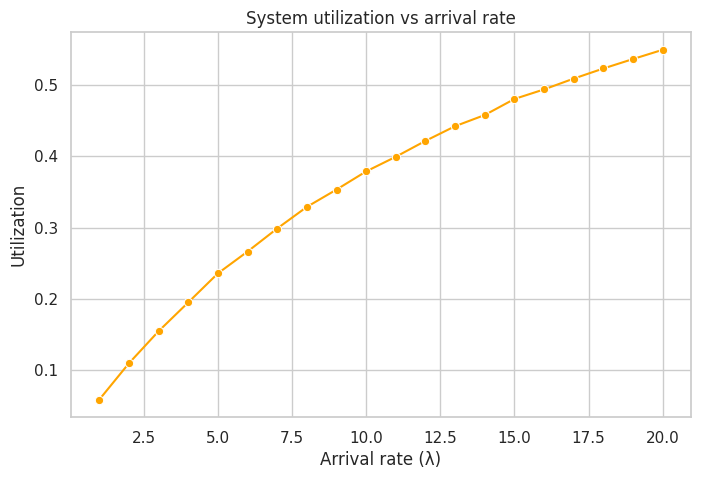

In [38]:
df_util = pd.DataFrame({
    "lambda": lambdas,
    "Utilization": utilizations
})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_util,
    x="lambda",
    y="Utilization",
    marker="o",
    color="orange"
)

plt.title("System utilization vs arrival rate")
plt.xlabel("Arrival rate (λ)")
plt.ylabel("Utilization")

plt.show()


### Пропускная способность

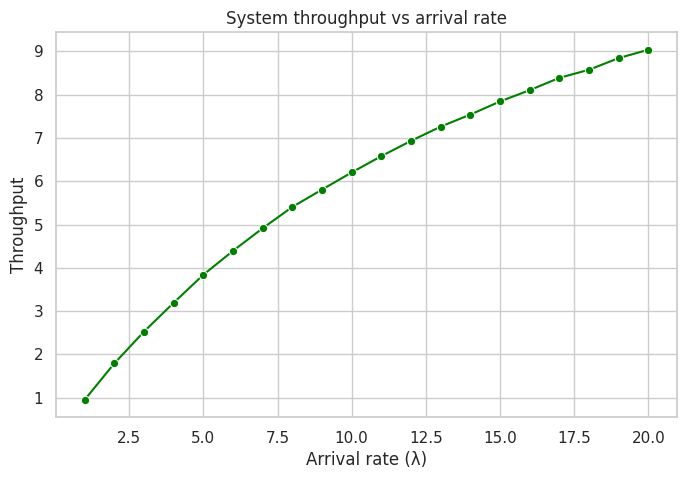

In [39]:
df_thr = pd.DataFrame({
    "lambda": lambdas,
    "Throughput": throughputs
})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_thr,
    x="lambda",
    y="Throughput",
    marker="o",
    color="green"
)

plt.title("System throughput vs arrival rate")
plt.xlabel("Arrival rate (λ)")
plt.ylabel("Throughput")

plt.show()

### Распределение времени выполнения запросов

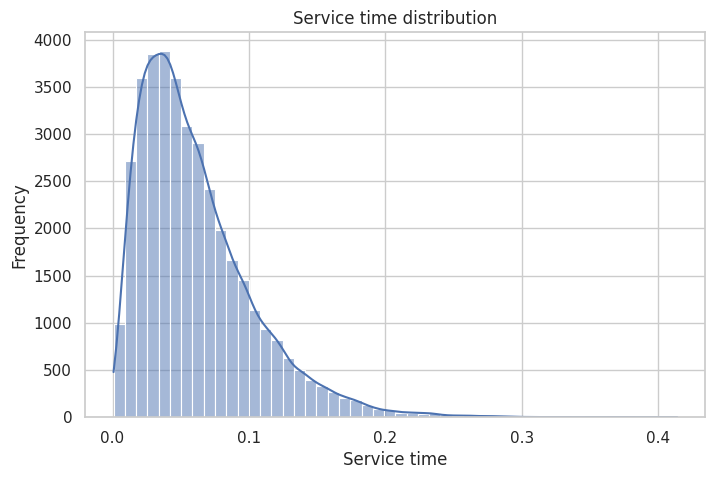

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    result["service_times"],
    bins=50,
    kde=True
)

plt.title("Service time distribution")
plt.xlabel("Service time")
plt.ylabel("Frequency")

plt.show()


### Временная диограмма

In [59]:
def plot_timeline(results, T):
    """Построение временной диаграммы"""
    requests_info = results['requests_info']
    colors = {'SET': '#2ecc71', 'GET': '#3498db', 'DELETE': '#e74c3c'}
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), 
                                   gridspec_kw={'height_ratios': [3, 1]})
    y_positions = {}
    current_y = 0
    
    served_requests = [r for r in requests_info if r['status'] == 'served']
    served_requests.sort(key=lambda x: x['arrival_time'])
    
    y_position = 0
    for request in served_requests:
        if request['status'] == 'served':
            found_position = False
            for pos in range(y_position + 1):
                if pos not in y_positions:
                    y_positions[pos] = []
                overlap = False
                for existing in y_positions[pos]:
                    if not (request['end_time'] <= existing['start_time'] or 
                           request['start_time'] >= existing['end_time']):
                        overlap = True
                        break
                
                if not overlap:
                    request['y_pos'] = pos
                    y_positions[pos].append(request)
                    found_position = True
                    break
            
            if not found_position:
                y_position += 1
                request['y_pos'] = y_position
                y_positions[y_position] = [request]
    
    for request in served_requests:
        y_pos = request['y_pos']
        rect = Rectangle((request['start_time'], y_pos - 0.4), 
                        request['end_time'] - request['start_time'], 0.8,
                        facecolor=colors[request['command']], 
                        edgecolor='black', alpha=0.7)
        ax1.add_patch(rect)
        current_x = request['start_time']
        rpc_rect = Rectangle((current_x, y_pos - 0.4), 
                            request['rpc_time'], 0.8,
                            facecolor=colors[request['command']], 
                            edgecolor='black', alpha=0.9)
        ax1.add_patch(rpc_rect)
        current_x += request['rpc_time']
        exec_rect = Rectangle((current_x, y_pos - 0.4), 
                             request['exec_time'], 0.8,
                             facecolor=colors[request['command']], 
                             edgecolor='black', alpha=0.7)
        ax1.add_patch(exec_rect)
        current_x += request['exec_time']
        resp_rect = Rectangle((current_x, y_pos - 0.4), 
                             request['resp_time'], 0.8,
                             facecolor=colors[request['command']], 
                             edgecolor='black', alpha=0.5)
        ax1.add_patch(resp_rect)

        ax1.plot([request['arrival_time'], request['arrival_time']], 
                [y_pos - 0.5, y_pos + 0.5], 
                color='black', linestyle='--', linewidth=1)
        ax1.text(request['start_time'] + (request['end_time'] - request['start_time'])/2, 
                y_pos, f"Req {request['id']}", 
                ha='center', va='center', fontsize=8, fontweight='bold')
    
    rejected_requests = [r for r in requests_info if r['status'] == 'rejected']
    max_y = max([r['y_pos'] for r in served_requests]) if served_requests else 5
    for request in rejected_requests:
        y_pos = max_y + 2
        ax1.plot(request['arrival_time'], y_pos, 'X', color='red', markersize=10, 
                markeredgecolor='black', markeredgewidth=1)
        ax1.text(request['arrival_time'], y_pos + 0.3, f"Req {request['id']}", 
                ha='center', va='bottom', fontsize=8, color='red')
    
    ax1.set_xlim(0, T)
    ax1.set_ylim(-1, max_y + 3)
    ax1.set_xlabel('Время')
    ax1.set_ylabel('Номер запроса')
    ax1.set_title('Временная диаграмма работы системы')
    ax1.grid(True, alpha=0.3)
    
    legend_elements = [mpatches.Patch(color=color, label=cmd, alpha=0.7) 
                      for cmd, color in colors.items()]
    legend_elements.extend([
        mpatches.Patch(color='black', alpha=0.9, label='RPC фаза'),
        mpatches.Patch(color='black', alpha=0.7, label='Execution фаза'),
        mpatches.Patch(color='black', alpha=0.5, label='Response фаза'),
        plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='red', 
                  markersize=10, label='Отклонен'),
        plt.Line2D([0], [0], linestyle='--', color='black', label='Прибытие')
    ])
    ax1.legend(handles=legend_elements, loc='upper right')
    
    time_points = np.linspace(0, T, 1000)
    server_load = []
    
    for t in time_points:
        busy = any(r['start_time'] <= t <= r['end_time'] 
                  for r in served_requests)
        server_load.append(1 if busy else 0)
    
    ax2.fill_between(time_points, 0, server_load, step='post', 
                     color='orange', alpha=0.7)
    ax2.set_xlim(0, T)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlabel('Время')
    ax2.set_ylabel('Загрузка')
    ax2.set_title('Загрузка сервера')
    ax2.grid(True, alpha=0.3)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Свободен', 'Занят'])
    
    plt.tight_layout()
    plt.show()

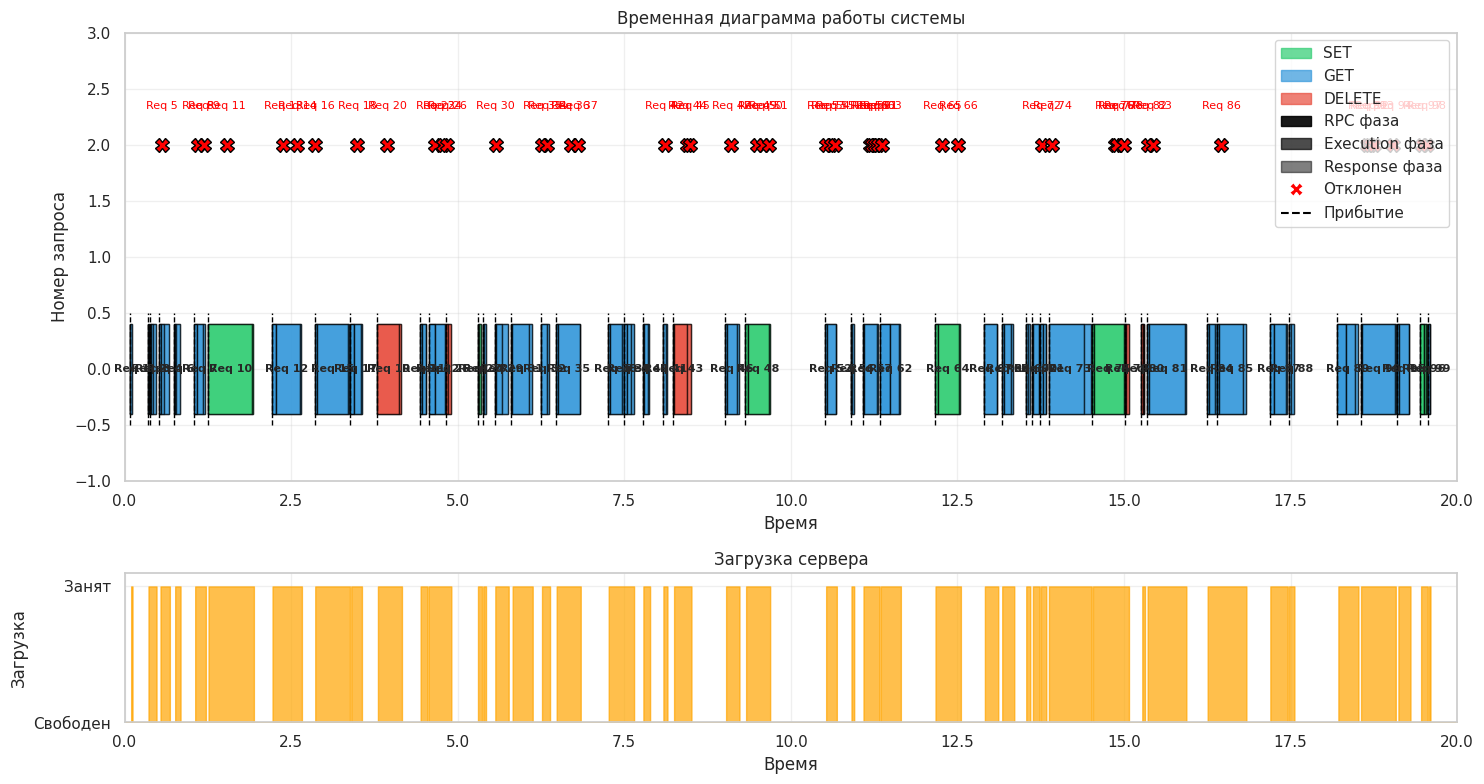

In [57]:
timeline_result = simulate_system(
    lam=5,
    mu_rpc=30,
    mu_resp=40,
    T=20,
    n=1000
)

plot_timeline(timeline_result, T=20)